<a href="https://colab.research.google.com/github/jylin04/mi-ntk/blob/main/modular_arithmetic_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup (run this and *'d cells at start)

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
import math

import numpy as np
import torch as t

from torch import nn, Tensor
from torch.nn import functional as F

from tqdm.notebook import tqdm

from typing import Tuple, Optional

import gc

In [3]:
import matplotlib.pyplot as plt

In [4]:
%pip install -q git+https://github.com/jylin04/mi-ntk.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [5]:
import ntk, ma

from ma import Quadratic, Scale, ModularArithmeticMLP
from ma import build_mod_arith_data, build_mod_arith_data_symbreak, train, test
from ntk import full_jacobian, class_jacobian, jacobian_by_layer, empirical_ntk, empirical_ntk_by_layer, LinearisedPredictor, eig_decompose
from ntk import axis_laplacians_pxp, two_stage_axis_diagonalization

In [6]:
# cfg
epochs: int = 5000
batch_size: int = 1024
lr: float = 1e-3
n_features: int = 80
n_hidden: int = 20
sparsity: float = 0.9
importance: float = 0.9

device = t.device("cuda" if t.cuda.is_available() else "cpu")
seed = 40

t.manual_seed(seed)

# Ground-truth feature basis

Used to make heat maps; we'll take their inner product with NTK eigenvectors or the equivalent.

In [14]:
def build_indicators(labels: t.Tensor, p: int):
    """
    labels : (N, 2) int array
             labels[:,0] = left digit (0-9)
             labels[:,1] = right digit (0-9)

    returns dict of {name: (N,) binary indicator}
    and     dict of {name: (N,10) one-hot matrix}  # for left/right/sum
    """
    left  = labels[:, 0]
    right = labels[:, 1]
    N     = len(labels)

    # --- A. atomic digit identity -----------------------------------------
    onehot = lambda v: np.eye(p, dtype=bool)[v]          # (N,p)

    left_onehot   = onehot(left)                          # (N,p)
    right_onehot  = onehot(right)

    # --- B. task-direct indicators ----------------------------------------
    sum_modp     = (left + right) % p
    sum_onehot    = onehot(sum_modp)

    carry_bit     = (left + right) >= p                  # (N,)
    same_parity   = (left % 2) == (right % 2)            # (N,)

    # --- C. low-order structure ------------------------------------------
    left_parity   = (left  % 2 == 1)                      # (N,)
    right_parity  = (right % 2 == 1)                      # (N,)
    same_digit    = left == right                         # (N,)

    # --- package ----------------------------------------------------------
    binary = {
        'carry'        : carry_bit,
        'same_parity'  : same_parity,
        'left_parity'  : left_parity,
        'right_parity' : right_parity,
        'same_digit'   : same_digit,
    }
    onehots = {
        'left_digit'   : left_onehot,    # each column k → “left digit = k”
        'right_digit'  : right_onehot,
        'sum_digit'    : sum_onehot,
    }
    return binary, onehots

In [15]:
binary, onehots = build_indicators(pairs.cpu().numpy(), params.p)

In [16]:
def fourier_cols(vals: np.ndarray, p: int) -> np.ndarray:
  """
  Build [cos(2π k val/p), sin(2π k val/p)] stacked column-wise.
  Return float32 array (N, floor(p//2), 2).
  """
  v = vals % p
  cols = []
  for k in range(1, p//2+1):
    ang = 2 * np.pi * k * v / p
    cols.append(np.stack((np.cos(ang), np.sin(ang)), axis=-1))  # (N, 2)
  F = np.stack(cols, axis=1).astype(np.float32)  # (N, floor(p//2), 2)
  return F


def build_fourier_features(labels: np.ndarray, p: int):
  """
  labels: (N,2) int array
  p     : modulus (odd)

  Returns: dict of real Fourier features:
    'n', 'm', 'sum', 'diff', '2n', '2m': (N, floor(p//2), 2)
    'readout': (N, p, floor(p//2), 2)
  """
  feats: Dict[str, np.ndarray] = {}

  left = labels[:, 0]
  right = labels[:, 1]

  # --- First-layer preactivation features ---------------------------------
  feats['n'] = fourier_cols(left, p)              #(N, floor(p//2), 2)
  feats['m'] = fourier_cols(right,p)

  # --- First-layer activation features ------------------------------------
  sum_mod  = (left + right) % p
  diff_mod = (left - right) % p
  feats['sum'] = fourier_cols(sum_mod, p)
  feats['diff'] = fourier_cols(diff_mod, p)
  feats['2n'] = fourier_cols(2 * left, p)
  feats['2m'] = fourier_cols(2 * right, p)

  # --- Second-layer preactivation features --------------------------------
  R = np.empty((labels.shape[0], p, p//2, 2))
  for q in range(p):
    R[:, q, :, :] = fourier_cols((sum_mod - q), p)
  feats['readout'] = R

  # --- Random vector control of shape (N, floor(p//2), 2) --------------------------------
  feats['ctrl'] = np.random.randn(fourier_cols(left,p).shape[0], fourier_cols(left,p).shape[1], fourier_cols(left,p).shape[2])


  return feats

In [17]:
feats = build_fourier_features(pairs.cpu().numpy(), params.p)

# Train the model & reproduce Fig. 2 in the paper

We reproduce Fig.2 before Fig.1 becuase in the process of reproducing Fig.2 we train the model.

In [7]:
# For this slightly smaller model than the one in Gromov, the eNTK fits in T4 GPU.

class HyperParams:
  p: int = 29
  width: int = 512
  #width: int = 64
  alpha: float = 0.7
  lr: float = 0.05
  epochs: int = 500
  eval_every: int = 200
  log_every: int = 10
  seed: int = 0

params = HyperParams()
t.manual_seed(params.seed)

device = t.device("cuda" if t.cuda.is_available() else "cpu")

In [8]:
# Train/test split
X, Y, y_idx, pairs = build_mod_arith_data(params.p, device=device)
#X, Y, y_idx, pairs = build_mod_arith_data_symbreak(params.p, device=device)

X_full = X
Y_full = Y

perm = t.randperm(X.shape[0], device=device)
n_train = int(X.shape[0] * params.alpha)          # Put this in manually: fraction of pairs in the training vs. test set.
idx_tr, idx_te = perm[:n_train], perm[n_train:]

x_train = X[idx_tr]
y_train = Y[idx_tr]

x_test = X[idx_te]
y_test = Y[idx_te]

In [9]:
from torch.utils.data import TensorDataset, DataLoader

train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size = len(x_train), shuffle=True)
test_loader = DataLoader(TensorDataset(x_test, y_test), batch_size = len(x_test), shuffle = False)

In [10]:
model = ModularArithmeticMLP(p=params.p, n_hidden=params.width, device=device)
opt = t.optim.AdamW(model.parameters(), lr = params.lr)

In [ ]:
# Naive training loop w/no bells and whistles

'''tr_loss = []
te_loss = []
tr_acc = []
te_acc = []

for epoch in range(params.epochs):
    train_loss = train(model, train_loader, opt, device)
    #train_loss = train(model, train_loader, opt, device, loss_fn = F.cross_entropy)
    if epoch % params.log_every == 0:
        tr_loss.append(train_loss)
        te_loss.append(F.mse_loss(model(x_test), y_test).item())
        #te_loss.append(F.cross_entropy(model(x_test), y_test).item())
        acc = test(model, test_loader, device)
        tr_acc.append(test(model, train_loader, device))
        te_acc.append(acc)
        print(f"Epoch {epoch}: Train loss {train_loss:.4f}, Accuracy {acc:.1f}")'''

Epoch 0: Train loss 0.0323, Accuracy 2.4
Epoch 10: Train loss 0.0311, Accuracy 0.0
Epoch 20: Train loss 0.0305, Accuracy 0.0
Epoch 30: Train loss 0.0296, Accuracy 0.0
Epoch 40: Train loss 0.0280, Accuracy 0.0
Epoch 50: Train loss 0.0248, Accuracy 0.0
Epoch 60: Train loss 0.0193, Accuracy 0.0
Epoch 70: Train loss 0.0122, Accuracy 1.8
Epoch 80: Train loss 0.0061, Accuracy 20.2
Epoch 90: Train loss 0.0029, Accuracy 59.6
Epoch 100: Train loss 0.0014, Accuracy 80.4
Epoch 110: Train loss 0.0007, Accuracy 87.5
Epoch 120: Train loss 0.0004, Accuracy 92.3
Epoch 130: Train loss 0.0002, Accuracy 94.4
Epoch 140: Train loss 0.0001, Accuracy 95.8
Epoch 150: Train loss 0.0001, Accuracy 96.7
Epoch 160: Train loss 0.0001, Accuracy 96.7
Epoch 170: Train loss 0.0000, Accuracy 96.7
Epoch 180: Train loss 0.0000, Accuracy 96.7
Epoch 190: Train loss 0.0000, Accuracy 97.0
Epoch 200: Train loss 0.0000, Accuracy 97.6
Epoch 210: Train loss 0.0000, Accuracy 97.9
Epoch 220: Train loss 0.0000, Accuracy 97.9
Epoch 2

In [13]:
def _mat(feats, key):
    # feats[key]: (N, K, 2) -> (N, 2K)
    F = feats[key].reshape(feats[key].shape[0], -1).astype(np.float64)
    F -= F.mean(0, keepdims=True)                    # drop constant mode
    return F

def _orth(X):
    # column-orthonormalize (works even if X not full rank)
    # also normalizes tiny-norm columns away
    q, _ = np.linalg.qr(X, mode="reduced")
    return q

def subspace_overlap(Q_cliff, feats, key):
    """
    Q_cliff: (N, d) eigenvectors for a cliff (columns, not rows)
    feats:   dict from your feature-bank builder
    key:     'axis_sum', 'axis2_sum', 'sum', 'diff', 'n', 'm', ...

    Returns:
      sing_vals: singular values of Q^T F (length <= min(d, 2K))
      overlap:   Frobenius^2 = sum(sing_vals**2) in [0, d]
    """
    Q = _orth(Q_cliff.astype(np.float64))
    F = _orth(_mat(feats, key))
    s = np.linalg.svd(Q.T @ F, compute_uv=False)
    return s, float((s**2).sum())

In [18]:
tr_loss = []
te_loss = []
tr_acc = []
te_acc = []
o_sums = []
o_diffs = []

for epoch in range(params.epochs):
    train_loss = train(model, train_loader, opt, device)
    #train_loss = train(model, train_loader, opt, device, loss_fn = F.cross_entropy)
    if epoch % params.log_every == 0:
        tr_loss.append(train_loss)
        te_loss.append(F.mse_loss(model(x_test), y_test).item())
        #te_loss.append(F.cross_entropy(model(x_test), y_test).item())
        acc = test(model, test_loader, device)
        tr_acc.append(test(model, train_loader, device))
        te_acc.append(acc)
        print(f"Epoch {epoch}: Train loss {train_loss:.4f}, Accuracy {acc:.1f}")

        entk = empirical_ntk_by_layer(model.to(device), t.Tensor(X_full).to(device), t.Tensor(X_full).to(device))
        entk_0 = entk['net.0']
        entk_3 = entk['net.3']
        eigvals, eigvecs = eig_decompose(entk_0.diagonal(dim1=2, dim2=3).mean(-1) + entk_3.diagonal(dim1=2, dim2=3).mean(-1), topk=200)
        c1 = eigvecs[:, 57:113]
        Q = c1.detach().cpu().numpy()
        _, o_sum  = subspace_overlap(Q, feats, key='sum')
        _, o_diff  = subspace_overlap(Q, feats, key='diff')
        o_sums.append(o_sum)
        o_diffs.append(o_diff)

        del entk
        del entk_0
        del entk_3
        gc.collect()
        t.cuda.empty_cache()

Epoch 0: Train loss 0.0343, Accuracy 2.4
Epoch 10: Train loss 0.0330, Accuracy 0.8
Epoch 20: Train loss 0.0324, Accuracy 0.4
Epoch 30: Train loss 0.0313, Accuracy 0.4
Epoch 40: Train loss 0.0293, Accuracy 0.0
Epoch 50: Train loss 0.0251, Accuracy 0.0
Epoch 60: Train loss 0.0183, Accuracy 0.8
Epoch 70: Train loss 0.0103, Accuracy 9.5
Epoch 80: Train loss 0.0045, Accuracy 52.2
Epoch 90: Train loss 0.0021, Accuracy 85.4
Epoch 100: Train loss 0.0009, Accuracy 93.7
Epoch 110: Train loss 0.0005, Accuracy 97.2
Epoch 120: Train loss 0.0002, Accuracy 98.4
Epoch 130: Train loss 0.0001, Accuracy 100.0
Epoch 140: Train loss 0.0001, Accuracy 100.0
Epoch 150: Train loss 0.0001, Accuracy 100.0
Epoch 160: Train loss 0.0000, Accuracy 100.0
Epoch 170: Train loss 0.0000, Accuracy 100.0
Epoch 180: Train loss 0.0000, Accuracy 100.0
Epoch 190: Train loss 0.0000, Accuracy 100.0
Epoch 200: Train loss 0.0000, Accuracy 100.0
Epoch 210: Train loss 0.0000, Accuracy 100.0
Epoch 220: Train loss 0.0000, Accuracy 100

In [30]:
o_sums_n = [x * 100 / 28 for x in o_sums]

In [31]:
def local_first_derivatives(y, dx=1.0):
    n = len(y)

    dydx = [0.0] * n

    # forward difference at left endpoint
    dydx[0] = (y[1] - y[0]) / dx

    # central difference in the interior
    for i in range(1, n - 1):
        dydx[i] = (y[i + 1] - y[i - 1]) / (2 * dx)

    # backward difference at right endpoint
    dydx[-1] = (y[-1] - y[-2]) / dx

    return dydx

In [32]:
o_1stderiv = local_first_derivatives(o_sums_n)

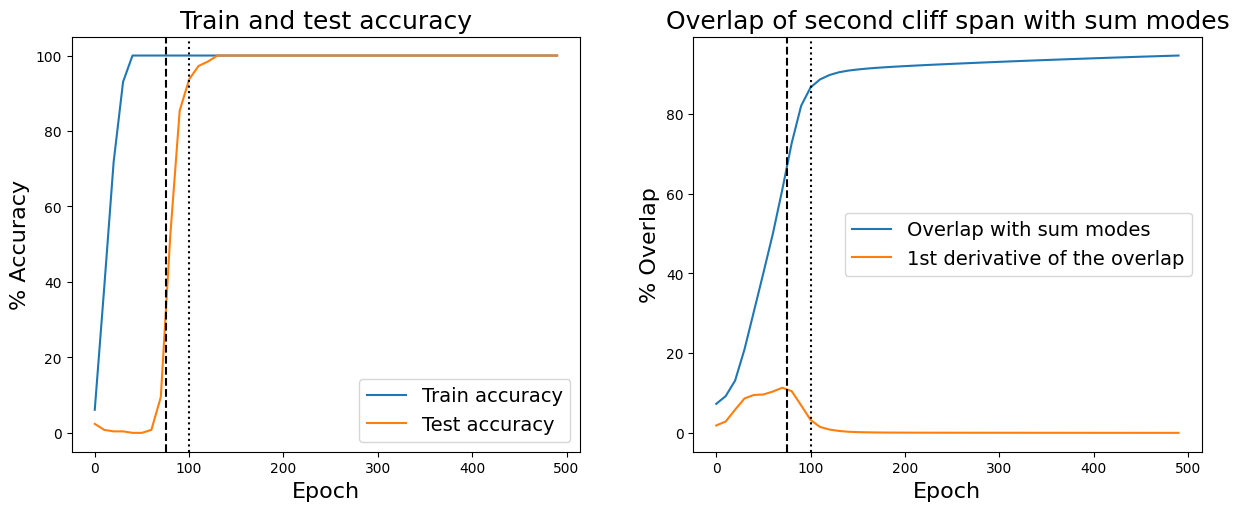

In [33]:
import numpy as np
import matplotlib.pyplot as plt

fig, axs = plt.subplots(
    1,2, figsize=(12, 5),
    #sharex='col', sharey='row',
    constrained_layout=True
)

fig.get_layout_engine().set(wspace=0.1)


x_axis = np.arange(start=0, stop=params.epochs, step=params.log_every)

axs[0].plot(x_axis, tr_acc, label="Train accuracy")
axs[0].plot(x_axis, te_acc, label="Test accuracy")
axs[0].axvline(x=75, linestyle="--", color="black")
axs[0].axvline(x=100, linestyle=":", color="black")
axs[0].set_xlabel("Epoch", fontsize=16)
axs[0].set_ylabel("% Accuracy", fontsize=16)
axs[0].set_title("Train and test accuracy", fontsize=18)
axs[0].legend(fontsize=14)
#axs[0].grid(True, alpha=0.3)
#axs[0].set_tight_layout()



x_axis_2 = np.arange(start=0, stop=params.epochs, step=params.log_every)

axs[1].plot(x_axis_2, o_sums_n, label = "Overlap with sum modes")
#axs[1].plot(x_axis_2, te_acc, label="Test accuracy")
axs[1].plot(x_axis_2, o_1stderiv, label = "1st derivative of the overlap")
#plt.plot(x_axis, o_diffs_n, label = "2nd cliff % overlap with diff modes")
axs[1].legend(fontsize=14)
axs[1].axvline(x=100, linestyle=":", color="black")
axs[1].axvline(x=75, linestyle="--", color="black")
axs[1].set_title("Overlap of second cliff span with sum modes", fontsize=18)  # eigenvectors 57-112
axs[1].set_xlabel("Epoch", fontsize=16)
axs[1].set_ylabel("% Overlap", fontsize=16)

plt.show()

# Reproduce Fig. 1

Text(0, 0.5, 'log(eigenvalue)')

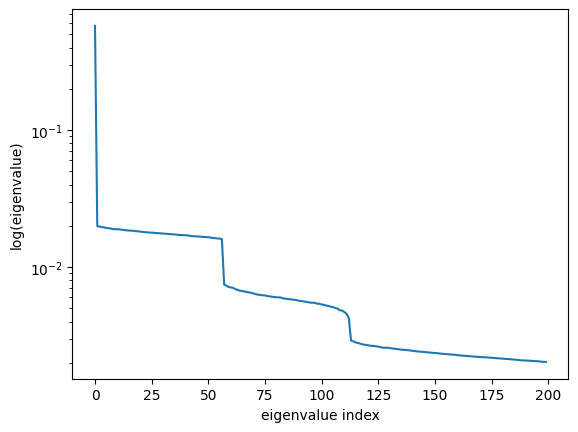

In [37]:
plt.plot(eigvals.detach().cpu().numpy())
plt.yscale('log')
#plt.title("Eigenvalue spectrum, per-class NTK (class(0,0)), layer 1 weights only, (p=29, n=512, α=0.7)")
plt.xlabel("eigenvalue index")
plt.ylabel("log(eigenvalue)")

# Reproduce Table 1

In [38]:
s, ov = subspace_overlap(Q, feats, key='diff')
print("singular values:", s, "   overlap:", ov)

singular values: [0.97262352 0.96952951 0.96930594 0.96696024 0.96676191 0.96489604
 0.96321386 0.96126737 0.96009993 0.9593744  0.9563     0.95504564
 0.95434222 0.95349841 0.95229806 0.9483105  0.94718729 0.94503884
 0.94209693 0.9408409  0.93732829 0.93478932 0.93347288 0.93104298
 0.92701554 0.92599488 0.91879566 0.90913726]    overlap: 25.214083388873014


In [39]:
_, o_sum  = subspace_overlap(Q, feats, key='sum')
_, o_diff  = subspace_overlap(Q, feats, key='diff')
print(o_sum, o_diff)

26.473990876550022 25.214083388873014
